## **Random Wallpaper Generator (DCGAN + Real-ESRGAN)**
CSE 25 - University of California, San Diego

**Team "The Best Boys":** Nathan Man, Christian Tchakmakjian, Sergio Pena, Samuel Suner

This project trains a DCGAN to generate wallpaper-style images from a paintings dataset, then upscales the generated outputs using Real-ESRGAN for higher resolution

Full training output run with images and checkpoints per epoch can be found at this Kaggle link: https://www.kaggle.com/code/nathantheman/cse-25-project-2-1/output

**1. Environment Setup**

Install the required libraries. We use a GitHub version of BasicSR, then install Real-ESRGAN and OpenCV for upscaling and image saving.

In [ ]:
# Documents
# https://docs.google.com/document/d/1jZRTY2QkfdHgBV1DeSqIqWBlBfyrehzE-NDmZDSpkNg/edit?tab=t.emntmwytr85c
#
#

# Clean old installs to avoid conflict versions
!pip uninstall -y basicsr realesrgan

# Install the UPDATED BasicSR (has the fix for functional_tensor)
# Framework of Real-ESRGAN, Real-ESRGAN cannot run without this
!pip install -q git+https://github.com/XPixelGroup/BasicSR.git

# Install Real-ESRGAN without letting it downgrade basicsr
# Real-ESRGAN are the upscaling models, used to upscale the best result, --no-deps prevents realesrgan from downgrading BasicSR
!pip install -q --no-deps realesrgan
# Facexlib is a library that helps Real-ESRGAN upscale faces (in the case that the wallpaper has one, detects and extracts them)
# gfpgan is a face restoration model
!pip install -q facexlib gfpgan
#OpenCV reads images, can resize images and save any image onto a folder
!pip install -q opencv-python

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 4.7 MB/s eta 0:00:00


**2. Download Dataset**

Download the paintings dataset from Kaggle. This dataset provides the images used to train the discriminator and teach the generator the artistic style.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("heyitsfahd/paintings")

# the paths are being exported onto the path variable. Stored at /kaggle/input/paintings
# The files are stored on the Colab virtual machine. You can see the files with the "files" button.
print("Path to dataset files:", path)

100%|██████████| 21.2M/21.2M [00:00<00:00, 85.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/heyitsfahd/paintings/versions/1


**3. Load File Names**

List the image files in the dataset folder so we can loop through them and build a training set.

In [ ]:
import os
# Import os allows us to save the files
# OS reads the files. It can also do different actions to the files on Colab

paintingFiles = os.listdir(path + "/paintings")
# A folder that has "paintings" at the end of it in the path variable
# will be the painting folder.
# for file in paintingFiles:
#     print(file)

In [ ]:
from PIL import Image
import numpy as np
import torch

# Prints the file path.
print(path + "/paintings/ABEKVGNN.jpg")
# Sets the image onto that variable, because the image ABEKVGNN is in the folder from the dataset.
img = Image.open(path + "/paintings/ABEKVGNN.jpg")
# Prints information regarding the file.
print(os.listdir(path))
print(os.listdir(path + "/paintings"))

/root/.cache/kagglehub/datasets/heyitsfahd/paintings/versions/1/paintings/ABEKVGNN.jpg
['paintings']
['UUMZPIBS.jpg', 'NAXHGKCK.jpg', 'XQTWJYMT.jpg', 'ODGAFZAF.jpg', 'VEYRFNLV.jpg', 'LCYVYSCD.jpg', 'PINHCBBP.jpg', 'INLFXJPS.jpg', 'LSMPQWJM.jpg', 'ZTRYUCUB.jpg', 'OGJVYLPZ.jpg', 'GYNFZNEF.jpg', 'TOSPBJBI.jpg', 'VEGOOSJI.jpg', 'AGEXDJEQ.jpg', 'XGPKRYYW.jpg', 'JDPOOCGU.jpg', 'EZHUEABQ.jpg', 'TEUFUHQG.jpg', 'PREFVREQ.jpg', 'CZGJNALK.jpg', 'RHXJRHXG.jpg', 'LKGCCXAO.jpg', 'YLOTPUQZ.jpg', 'PJQXIRRX.jpg', 'JMMQFEGI.jpg', 'HPHSTFIA.jpg', 'XJIDTMDI.jpg', 'RIDFZMWG.jpg', 'REIOCZZJ.jpg', 'OKYWPBRS.jpg', 'XXJUIROY.jpg', 'PNJYVQVX.jpg', 'SGPRABAI.jpg', 'KTJGUEUE.jpg', 'VHJYGXTY.jpg', 'DCEBPKNW.jpg', 'ELJESZPR.jpg', 'ICWBITNS.jpg', 'ZLZTMOZQ.jpg', 'SBDKYFBL.jpg', 'MDTRAVVB.jpg', 'WSEBUPOZ.jpg', 'QORLFKKE.jpg', 'ILRRFJFV.jpg', 'QYMVAJHC.jpg', 'KWKGTVRO.jpg', 'FQCSBWBC.jpg', 'YBIQFUJB.jpg', 'QEEFTMZF.jpg', 'OGWQRLAT.jpg', 'NENJFEQU.jpg', 'JYXANHOG.jpg', 'GGOWJDED.jpg', 'QPOOOWAJ.jpg', 'UTSMHPCR.jpg', 'H

**4. Preprocess Images (Resize and Normalize)**

Load each image, convert to RGB, resize to 128×128, convert to a tensor, and normalize pixel values to [-1, 1] to match the generator’s output.

In [ ]:
#loading images

images = []
# Loops through every image in the paintingFiles folder,
#paintingFiles = os.listdir(path + "/paintings")
for fileName in paintingFiles:
    file_path = os.path.join(path + "/paintings", fileName)
    # Scans for images that end with that file extension at the end of it.
    if not fileName.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        # Skip any files that do not end with any of the extensions above.
        continue
    # Assigns the image it is reading 3 channels, RGB. The image is a "PIL object".
    img = Image.open(file_path).convert("RGB")
    # An image in the painting dataset is resized to 128x128.
    img = img.resize((128, 128))
    # The image is converted into an array.
    # The image is an array of arrays of arrays. The structure is:
    # [] <- Main array for each image, [][][], the 3 dimensions in the array, including the
    # width, height, and the channel, and [][][], the red, green, and blue values of each pixel of
    # the image.
    # Because the type of array is a numPy array, img_array's third dimension does not store
    # pixels. It does help in creating the RGB array, though.
    # Every RGB pixel array is resized to a number between 0 and 1.
    img_array = np.array(img).astype(np.float32) / 255.0   # (H, W, C)
    # The order of the array is edited. The channel is now the first dimension of the array.
    # The width is now the second dimension of the array, and the height is now the third dimension.
    img_array = np.transpose(img_array, (2, 0, 1))
    # Every normalized pixel value is now set into a number that is in between
    # negative one and one.
    img_array = (img_array * 2.0) - 1.0


    images.append(img_array)
x = np.array(images)

In [ ]:
# The first image is x[0]
# The red channel of that image is x[0][0], green is x[0][1], blue is x[0][2]
# The first row of the red channel is x[0][0][0]
# The first pixel of that row is x[0][0][0][0], represented as an np.float32
# from -1 to 1
x[0]

array([[[-0.29411763, -0.4588235 , -0.4980392 , ..., -0.64705884,
         -0.6862745 , -0.27843136],
        [-0.4352941 , -0.16862744, -0.42745095, ..., -0.35686272,
         -0.62352943, -0.56078434],
        [-0.52156866, -0.35686272, -0.3098039 , ..., -0.31764704,
         -0.52156866, -0.47450978],
        ...,
        [-0.6862745 , -0.6862745 , -0.70980394, ..., -0.30196077,
         -0.36470586, -0.47450978],
        [-0.6862745 , -0.6       , -0.62352943, ..., -0.04313725,
         -0.67058825, -0.77254903],
        [-0.6       , -0.46666664, -0.52156866, ...,  0.3803922 ,
         -0.18431371, -0.5686275 ]],

       [[-0.29411763, -0.45098037, -0.49019605, ..., -0.4823529 ,
         -0.5294118 , -0.12156862],
        [-0.4352941 , -0.16862744, -0.41960782, ..., -0.19215685,
         -0.46666664, -0.40392154],
        [-0.54509807, -0.36470586, -0.3098039 , ..., -0.15294117,
         -0.36470586, -0.31764704],
        ...,
        [-0.58431375, -0.58431375, -0.6156863 , ..., -

**5. Create DataLoader**

Create a PyTorch DataLoader to batch and shuffle images during training. This improves training efficiency.

In [ ]:
# Dataloader creates batches of 64 images, because you cannot train off of all images at once.
# If you train off all images at once, it will be too much for the VM.
# It is also bad for generating the wallpapers
dataloader = torch.utils.data.DataLoader(x, batch_size = 64, shuffle = True)
device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")

## **6. Model: Discriminator**
Contains the discriminator. Its purpose is to classify images as real (from the dataset) or fake (from the generator)

In [ ]:
# import torch
# import torch.nn as nn

# class Discriminator(nn.Module):
#   def __init__(self) -> None:
#     super().__init__()
#     # Takes input of 3 channels,
#     # outputs 64 feature maps,
#     # halves the revolution (128x128 turns into 64x64) because
#     # K is kernel size, which is 4, S is stride, which is 2,
#     # and P is padding, which is 1.
#     # (Channels, feature maps, kernel size, stride, padding)
#     # The formula for the output width/height is (W-K+2P/S)+1
#     # So the resolution is halved
#     # Stride represents how far the discriminator checks each step, moves 2 pixels
#     # Padding is what keeps the edges aligned (if it is set to 1.)
#     # Kernel size is how big of a patch the convolutional layer of the discriminator
#     # is. Kernel_size being 4 means its looking at a 4x4 square. Padding also adds
#     # "fake" pixels around the border so that things can align. 1 pixel is added
#     # as a border around the 64x64 square, so the total image size is
#     # 130x130..
#     self.model = nn.Sequential(
#       nn.Conv2d(3, 64, 4, 2, 1),
#       nn.LeakyReLU(0.2, inplace = True),

#       nn.Conv2d(64, 128, 4, 2, 1),
#       nn.BatchNorm2d(128),
#       nn.LeakyReLU(0.2, inplace = True),

#       nn.Conv2d(128, 256, 4, 2, 1),
#       nn.BatchNorm2d(256),
#       nn.LeakyReLU(0.2, inplace = True),

#       nn.Conv2d(256, 512, 4, 2, 1),
#       nn.BatchNorm2d(512),
#       nn.LeakyReLU(0.2, inplace = True),

#       nn.Conv2d(512, 1024, 4, 1, 0),
#       nn.BatchNorm2d(1024),
#       nn.LeakyReLU(0.2, inplace = True),

#       nn.Conv2d(1024, 1, 4, 1, 0),
#       nn.Flatten(),
#       nn.Linear(4, 8),
#       nn.Linear(8, 1),

#       nn.Sigmoid()
#     )
#   def forward(self, x):
#     return self.model(x)

import torch
import torch.nn as nn

class Discriminator(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.model = nn.Sequential(
      nn.Conv2d(3, 64, 4, 2, 1),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(64, 128, 4, 2, 1),
      nn.BatchNorm2d(128),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(128, 256, 4, 2, 1),
      nn.BatchNorm2d(256),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(256, 512, 4, 2, 1),
      nn.BatchNorm2d(512),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(512, 1024, 4, 2, 1),
      # nn.BatchNorm2d(1024),
      nn.LeakyReLU(0.2, inplace = True),

      nn.Conv2d(1024, 1, 4, 1, 0),
      # nn.Flatten(),
      # nn.Linear(4, 8),
      # nn.Linear(8, 1),

      # nn.Sigmoid()
    )
  def forward(self, x):
    return self.model(x)

In [ ]:
# Puts the discriminator into the variable "discriminator".
# Moves it onto the CPU or GPU of the VM.
discriminator = Discriminator().to(device)

## **7. Check: Discriminator output**
Run a forward pass on a single real image to confirm the discriminator runs without shape errors.

In [ ]:
# The NumPy image is converted into a tensor.
# The tensor is a number container with a shape, i.e. used for generalizing the image here.
# The image tensors look something like this: (batch, channel, height, width).
img_tensor = torch.from_numpy(x[0]).float().to(device)
img_tensor = img_tensor.unsqueeze(0)
discriminator.eval()
with torch.no_grad():
    prediction = discriminator(img_tensor)

print(prediction)

tensor([[[[-0.0083]]]], device='cuda:0')


## **8. Model: Generator (DCGAN)**
Contains the generator. The generator takes a random noise vector as input and gradually increases its size using upsampling convolution layers until it produces a 128 × 128 RGB image.

In [ ]:
class Generator(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.model = nn.Sequential(
      nn.ConvTranspose2d(100, 1024, 4, 1, 0, bias = False),
      nn.BatchNorm2d(1024),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias = False),
      nn.BatchNorm2d(512),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(512, 256, 4, 2, 1, bias = False),
      nn.BatchNorm2d(256),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(256, 128, 4, 2, 1, bias = False),
      nn.BatchNorm2d(128),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(128, 64, 4, 2, 1, bias = False),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace = True),

      nn.ConvTranspose2d(64, 3, 4, 2, 1, bias = False),
      nn.Tanh()
    )
  def forward(self, x):
    return self.model(x)

In [ ]:
# Create a generator object / set it to the variable with completely random weights.
# These weights will be shifted during training.
generator = Generator().to(device)

In [ ]:
generator

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Batch

In [ ]:
# The noise code, giving a randomly-patterned, 3 x 128 x 128 tensor
# (Batch, latent dim, height, width). The generator's input, which is a set of random numbers
# from a normal distribution (bell curve).
noise = torch.randn(1, 100, 1, 1).to(device)

In [ ]:
# generator.eval() sets the generator into a mode that evaluates
generator.eval()
# "with torch.no_grad()" says to not track gradients yet
with torch.no_grad():
    generation = generator(noise)
    classification = discriminator(generation)


In [ ]:
# Reshapes the tensor to match the shape of the image.
# The generated image is forced into that shape.
# The tensor is now put into a CPU because NumPy cannot read GPU memory.
# .detach() is there because PyTorch is not tracking gradients yet.
# After you call this once, it will error if you call it again because .cpu()
# is now a numPy array. It iwll not have .cpu(). The generation
# variable is a tensor by the time you run this code the first time.

generation = generation[0].cpu().detach().numpy()

**9. Check: Generator output**

Generate a sample image using random noise and visualize it to confirm the generator runs correctly before starting training.

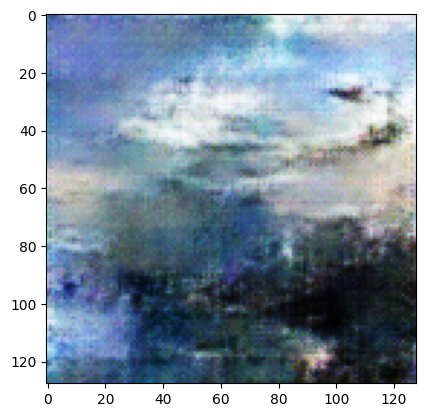

In [ ]:
import matplotlib.pyplot as plt
# plt.imshow(generation.reshape((128, 128, 3)))
# print(generation.reshape(128,128,3))

# The print line shows that the array is a bunch of small values (1e-6 to 1e-4)
# so I'm going to edit the way it renders this a bit so we can see the
# untrained data better.

# The generation is represented as (channel, height, width) at the moment
# normalizedimg normalizes the values from negative to 1, -1+1/2 turns into 0
# while 0 (0+1/2) turns into 1/2 until 1 is reached (1 is the max).
# normalizedimg is a numpy array
# print(generation.shape)
  # print(generation.min(), generation.max())
    # -0.0010235575 0.0010415884

normalizedimg = (generation + 1) / 2
normalizedimg = normalizedimg.transpose(1, 2, 0)
# print(normalizedimg)
plt.imshow(normalizedimg)
plt.show()

In [ ]:
prediction

tensor([[[[-0.0083]]]], device='cuda:0')

## **10. Training**
In this step we prepare everything needed for training the GAN model. This includes the loss function, setting up the adam optimizers, creating fixed noise for consistent image generation, and defining labels for real and fake images.

In [ ]:
import torch.optim as optim
import torchvision.utils as vutils

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
criterion = nn.BCEWithLogitsLoss()

fixed_noise = torch.randn(64, 100, 1, 1, device=device)

true_label = 1.0
false_label = 0.0

discriminator_optimizer = optim.Adam(discriminator.parameters(), lr = 1e-4, betas = (0.5, 0.999))
generator_optimizer = optim.Adam(generator.parameters(), lr = 2e-4, betas = (0.5, 0.999))
generator.apply(weights_init)
discriminator.apply(weights_init)
generator.train()
discriminator.train()

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (12): LeakyReLU(negative_slope=0.2, inplace=True)
    (13): Conv2d(1024, 1, kernel_size=(4, 

**11. Training the DCGAN model**

This section runs the main training loop for the GAN. The generator and discriminator are trained together. During training we also save generated images and model checkpoints so we can track the model’s progress.

In [ ]:
#--------------------------
# import the torch pretrained uniqueness loss model
#import torch.nn.functional as F
#https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html
#import torchvision.models as models
# Pretrained VGG16 feature extractor
#vgg = models.vgg16(pretrained=True).features.to(device)
#vgg.eval()
# Freezing the VGG parameters (to not train it)
#for p in vgg.parameters():
#    p.requires_grad = False
# --------------------------
import time
img_list = []
generator_losses = []
discriminator_losses = []
iters = 0
start_time = time.time()
print("Training starting")

num_epochs = 100
for epoch in range(num_epochs):
  # ---------------------------------------------
  # Calculates an ETA until training num_epochs is finished
  # remember that time.time() is seconds since 1970
  time_elapsed = time.time() - start_time
  time_left = ((time_elapsed / (epoch + 1))*((num_epochs) - (epoch+1)))
  hours = int(time_left // 3600)
  minutes = int((time_left % 3600) // 60)
  seconds = int(time_left % 60)
  current_time = time.strftime("%H:%M:%S", time.localtime())
  # two decimal places
  print(f"ETA: {hours:02d}:{minutes:02d}:{seconds:02d}" + "- Current time: " + current_time)
  # ---------------------------------------------
  for i, data in enumerate(dataloader, 0):
    #train with real batch
    discriminator.zero_grad()

    true_gpu = data.float().to(device)

    # noise that helps stabilize GAN training (helps prevents discriminator overfitting)
    true_gpu = true_gpu + 0.05 * torch.randn_like(true_gpu)
    true_gpu = torch.clamp(true_gpu, -1, 1)

    batch_size = true_gpu.size(0)
    label = torch.full((batch_size,), true_label, dtype = torch.float, device = device)
    output = discriminator(true_gpu).view(-1)
    discriminatorErrorTrue = criterion(output, label)

    discriminatorErrorTrue.backward()
    discriminatorX = output.mean().item()
    #train with all fake batch
    noise = torch.randn(batch_size, 100, 1, 1, device = device)
    fake = generator(noise)
    fake = fake + 0.05 * torch.randn_like(fake)
    fake = torch.clamp(fake, -1, 1)
    label.fill_(false_label)
    output = discriminator(fake.detach()).view(-1)

    discriminatorErrorFake = criterion(output, label)
    discriminatorErrorFake.backward()
    discriminatorF = output.mean().item()

    discriminatorError = discriminatorErrorTrue + discriminatorErrorFake
    discriminator_optimizer.step()

    #update discriminator
    generator.zero_grad()
    label.fill_(true_label)
    output = discriminator(fake).view(-1)
    generatorError = criterion(output, label)
    #--------------------------------
    # rate of the uniqueness loss
    # fake_features = vgg(fake)
    # shifted = torch.roll(fake_features, 1, 0)
    # uniqueness_loss = F.mse_loss(fake_features, shifted)
    # uniqueness_rate_factor = 0.001
    # generatorError = generator_loss + (uniqueness_rate_factor * uniqueness_loss)
    # Samuel's note: I used "generator loss" in a copy of this project to record both
    # the uniqueness loss and the generator loss separately. This code will not
    # work with the current code because of the checkpoint block below, as that
    # restores the data this model had in epoch 110 of its training. To make it
    # work, you'd have to replace "generator_loss" with generatorError, except
    # you wouldn't be able to record the generator's loss.
    #-------------------------------

    generatorError.backward()
    discriminatorG = output.mean().item()
    generator_optimizer.step()

    if i % 50 == 0:
      print(f"[{epoch}/{num_epochs}][{i}/{len(dataloader)}] "
            f"Loss_D: {discriminatorError.item():.4f} "
            f"Loss_G: {generatorError.item():.4f} "
            f"D(x): {discriminatorX:.4f} "
            f"D(G(z)): {discriminatorF:.4f} / {discriminatorG:.4f}")
    generator_losses.append(generatorError.item())
    discriminator_losses.append(discriminatorError.item())

    if iters % 500 == 0 or i == len(dataloader)-1:
      with torch.no_grad():
        fake = generator(fixed_noise).detach().cpu()
      os.makedirs("generated", exist_ok=True)
      vutils.save_image(fake, f"generated/epoch_{epoch:03d}.png", normalize=True, value_range=(-1, 1))

        # Save model checkpoints (generator + discriminator)
      os.makedirs("checkpoints", exist_ok=True)
      torch.save(generator.state_dict(), f"checkpoints/G_epoch_{epoch:03d}.pth")
      torch.save(discriminator.state_dict(), f"checkpoints/D_epoch_{epoch:03d}.pth")

      img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

    iters += 1


Training starting
ETA: 00:00:00- Current time: 00:02:12
[0/100][0/77] Loss_D: 2.2454 Loss_G: 14.9632 D(x): 0.7471 D(G(z)): 1.1528 / -14.9632
[0/100][50/77] Loss_D: 0.4249 Loss_G: 17.2310 D(x): 8.8515 D(G(z)): -18.8083 / -17.2310
ETA: 00:22:36- Current time: 00:02:40
[1/100][0/77] Loss_D: 1.2113 Loss_G: 41.8101 D(x): 6.1792 D(G(z)): -38.6516 / -41.8101
[1/100][50/77] Loss_D: 0.7539 Loss_G: 12.7968 D(x): 9.7132 D(G(z)): -5.7049 / -12.7935
ETA: 00:29:35- Current time: 00:03:07


KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load("/content/gan_checkpoint_epoch110.pth", map_location=device)

# Load model weights
generator.load_state_dict(checkpoint['generator_state_dict'])

<All keys matched successfully>

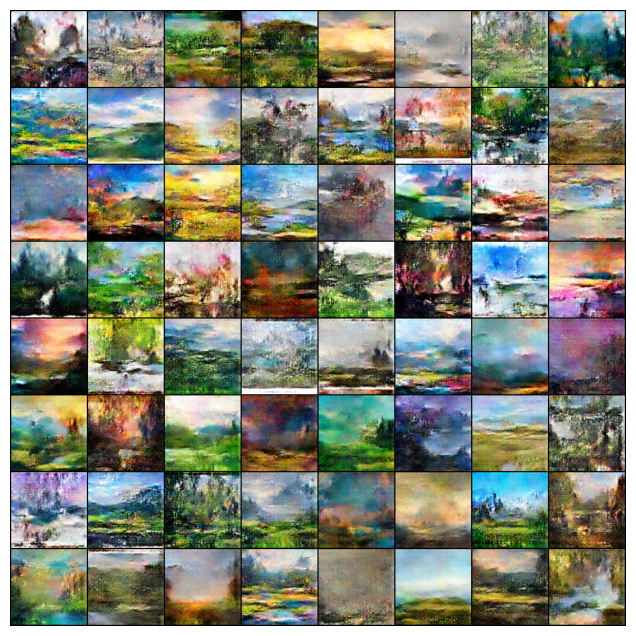

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

generator.eval()

noise = torch.randn(64, 100, 1, 1).to(device)  # 64 images for a full grid

with torch.no_grad():
    fake = generator(noise).detach().cpu()

# Create grid (same as save_image internally)
grid = vutils.make_grid(fake, normalize=True, value_range=(-1, 1), nrow=8)

# Convert to (H, W, C) for plotting
grid = grid.permute(1, 2, 0).numpy()

# Show the grid
plt.figure(figsize=(8, 8))
plt.imshow(grid)
plt.axis("off")
plt.show()

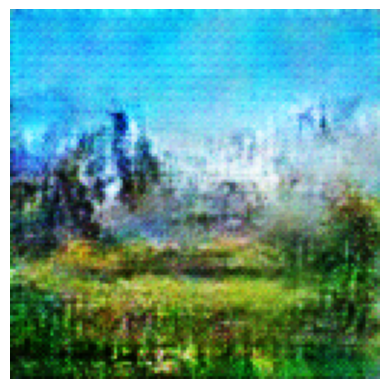

In [ ]:
img = fake[54].numpy()

# Normalize from [-1, 1] → [0, 1]
img = (img + 1) / 2

# Change from (C, H, W) → (H, W, C)
img = img.transpose(1, 2, 0)
plt.imshow(img)
plt.axis("off")
plt.show()

**12. Saving generated images**

Save one of the generated image grids so that we can easily view the training progress outside the notebook.

In [ ]:
plt.imsave("./" + str(epoch) + "-generation.png", img_list[-1].permute(1, 2, 0))

**13. Upscaling Setup (Real-ESRGAN Imports)**

Import the libraries needed to use Real-ESRGAN. This model will later be used to increase the resolution of the wallpapers.

In [ ]:
# Imports for upscaling

from realesrgan import RealESRGANer  # Real-ESRGAN upscaler helper
from basicsr.archs.rrdbnet_arch import RRDBNet  # The neural network shape Real-ESRGAN uses

import torch  # GPU/CPU
import os     # folders/files
import cv2    # read/write images for RealESRGANer
import numpy as np  # arrays (sometimes useful)

**14. Download Real-ESRGAN models**

Download the pretrained Real-ESRGAN models. The x4 model produces standard upscaling, while the x4plus model produces slightly better image quality.

In [ ]:
# Download the pretrained ESRGAN models (used to upscale images)

# Improved ESRGAN model (better quality)
!wget -nc https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth

# Standard realesr-general-x4v3
!wget -nc https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.5.0/realesr-general-x4v3.pth

import torch

--2026-03-19 04:21:40--  https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/387326890/08f0e941-ebb7-48f0-9d6a-73e87b710e7e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-19T05%3A14%3A26Z&rscd=attachment%3B+filename%3DRealESRGAN_x4plus.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-19T04%3A13%3A34Z&ske=2026-03-19T05%3A14%3A26Z&sks=b&skv=2018-11-09&sig=yDNxdpV1LVc6wrdKOj%2Fflh7JCw2ohgKaKTCui%2FEEpB4%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3Mzg5NTkwMSwibmJmIjoxNzczODk0MTAxLCJwYXRoIjoicmVsZWFzZWFzc2V0cH

**15. Notes on Original x4 Model**

In [ ]:
# NOTE:
# We initially attempted to use the original Real-ESRGAN x4 model.
# However, it caused compatibility issues during weight loading.
# To address this, we used the working realesr-general-x4v3 model
# together with the Real-ESRGAN x4plus model for our upscaling experiments.

**16. Create Output Folders**

Create the folders where generated images and upscaled results will be saved.

In [ ]:
# Creates folder when GAN saves images
import os
os.makedirs("generated", exist_ok=True)
print("Folder 'generated' is ready")

Folder 'generated' is ready


## **17. Upscaling Generated Images (x4)**
This function goes through the images inside the generated folder and upscales them using the Real-ESRGAN x4 model. The upscaled images are then saved in the upscaled folder.

In [ ]:
# This function upscales generated GAN images using the realesr-general-x4v3 model.

from realesrgan.archs.srvgg_arch import SRVGGNetCompact

def upscale_generated_image_general(input_image,
                                    output_folder="upscaled_general_x4v3",
                                    scale=4):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    os.makedirs(output_folder, exist_ok=True)

    if not os.path.exists(input_image):
        print("Input image not found:", input_image)
        return

    # realesr-general-x4v3 uses the SRVGG architecture
    model = SRVGGNetCompact(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_conv=32,
        upscale=4,
        act_type='prelu'
    )

    weights_path = "realesr-general-x4v3.pth"
    if not os.path.exists(weights_path):
        print("Missing weights:", weights_path)
        return

    upsampler = RealESRGANer(
        scale=scale,
        model_path=weights_path,
        model=model,
        tile=0,
        tile_pad=10,
        pre_pad=0,
        half=(device == "cuda"),
        gpu_id=0 if device == "cuda" else None
    )

    filename = os.path.basename(input_image)

    if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
        print("Unsupported file type:", filename)
        return

    input_path = input_image
    output_path = os.path.join(output_folder, "general_x4v3_" + filename)

    img = cv2.imread(input_path, cv2.IMREAD_COLOR)
    if img is None:
        print("Could not read:", input_path)
        return

    output, _ = upsampler.enhance(img, outscale=scale)
    cv2.imwrite(output_path, output)
    print("Saved (general-x4v3):", output_path)

## **18. Improved Upscaling (x4plus)**
This function tries to use the improved x4plus model to upscale the images. If the x4plus model is not available, the code automatically go back to the x4 model

In [ ]:
# This function goes to the input_folder where GAN images are saved.
# It tries to use the improved x4plus ESRGAN.
# If that is not available, it uses the normal x4 instead.

def esrgan_upscale_plus(input_image, output_folder="upscale_esrgan_plus", scale=4):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    os.makedirs(output_folder, exist_ok=True)

    if not os.path.exists(input_image):
        print("Input image not found:", input_image)
        return

    model = RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
        scale=scale
    )

    # Pick which weights file to use
    weights_path = "RealESRGAN_x4plus.pth"
    if os.path.exists(weights_path):
        print("Loaded x4plus weights.")
    else:
        print("x4plus not found, using realesr-general-x4v3 instead")
        weights_path = "realesr-general-x4v3.pth"

        if not os.path.exists(weights_path):
            print("Missing fallback weights too:", weights_path)
            return

    upsampler = RealESRGANer(
        scale=scale,
        model_path=weights_path,
        model=model,
        tile=0,
        tile_pad=10,
        pre_pad=0,
        half=(device == "cuda"),
        gpu_id=0 if device == "cuda" else None
    )

    filename = os.path.basename(input_image)

    if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
        print("Unsupported file type:", filename)
        return

    output_path = os.path.join(output_folder, "x4plus_" + filename)

    img = cv2.imread(input_image, cv2.IMREAD_COLOR)
    if img is None:
        print("Could not read:", input_image)
        return

    output, _ = upsampler.enhance(img, outscale=scale)
    cv2.imwrite(output_path, output)
    print("Saved (x4plus):", output_path)

**19. Upscale the Best Generated Image**

Upscale a selected best epoch image so we can produce a final high-quality wallpaper without upscaling everything.

In [ ]:
def upscale_one_x4plus(filename="generated/epoch_049.png", out_folder="final_upscaled_x4plus"):
    os.makedirs(out_folder, exist_ok=True)

    model = RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
        scale=4
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"

    upsampler = RealESRGANer(
        scale=4,
        model_path="RealESRGAN_x4plus.pth",
        model=model,
        tile=0,
        tile_pad=10,
        pre_pad=0,
        half=(device == "cuda"),
        gpu_id=0 if device == "cuda" else None
    )

    img = cv2.imread(filename, cv2.IMREAD_COLOR)
    output, _ = upsampler.enhance(img, outscale=4)

    out_path = os.path.join(out_folder, "x4plus_" + os.path.basename(filename))
    cv2.imwrite(out_path, output)
    print("Saved:", out_path)

upscale_one_x4plus("download (3).png")
esrgan_upscale_plus("download (3).png")
upscale_generated_image_general("download (3).png")

Saved: final_upscaled_x4plus/x4plus_download (3).png
Device: cuda
Loaded x4plus weights.
Saved (x4plus): upscale_esrgan_plus/x4plus_download (3).png
Saved (general-x4v3): upscaled_general_x4v3/general_x4v3_download (3).png


**20. Run the Upscaling functions**

Run the upscaling functions. Outputs will be saved to:

*   final_upscaled: the selected best image

*   upscaled: images upscaled with the x4 model

*   upscale_esrgan_plus: images upscaled with the x4plus model







In [ ]:
# upscale_generated_images_general()  # Runs realesr-general-x4v3 (general comparison model)
esrgan_upscale_plus()               # Runs Real-ESRGAN x4plus (best quality model)

Saved (general-x4v3): upscaled_general_x4v3/general_x4v3_epoch_000.png
Saved (general-x4v3): upscaled_general_x4v3/general_x4v3_epoch_001.png
Device: cuda
Found 2 files in generated
Loaded x4plus weights.
Saved (x4plus): upscale_esrgan_plus/x4plus_epoch_000.png
Saved (x4plus): upscale_esrgan_plus/x4plus_epoch_001.png


**21. Final Upscaling Comparison**

 This section compares the original GAN output with the two upscaling models.
We compare:
- Real-ESRGAN x4plus (sharper, higher detail)
- realesr-general-x4v3 (smoother, general model)

The goal is to evaluate which model produces better visual quality. Based on this comparison, we conclude x4plus is selected as the final model.

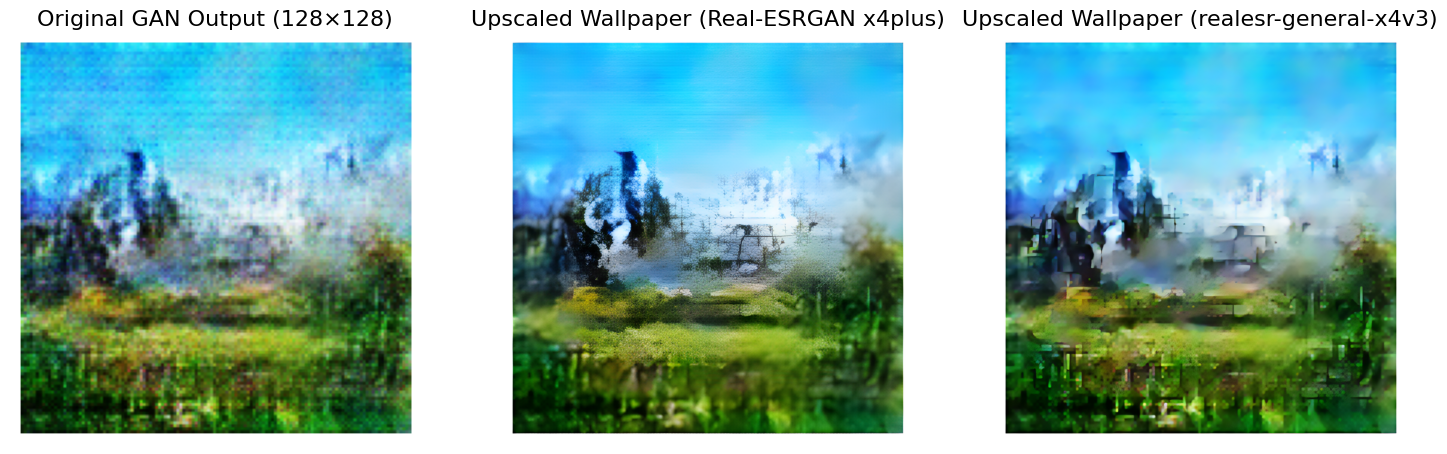

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Load the original generated image (low-resolution GAN output)
orig = cv2.cvtColor(cv2.imread("download (3).png"), cv2.COLOR_BGR2RGB)

# Load the upscaled image using Real-ESRGAN x4plus (sharper, high-detail model)
x4plus = cv2.cvtColor(cv2.imread("final_upscaled_x4plus/x4plus_download (3).png"), cv2.COLOR_BGR2RGB)

# Load the upscaled image using realesr-general-x4v3 (general-purpose model)
general = cv2.cvtColor(cv2.imread("upscaled_general_x4v3/general_x4v3_download (3).png"), cv2.COLOR_BGR2RGB)

# Create a figure to compare all three images side by side
plt.figure(figsize=(18,6))

# Display original GAN output
plt.subplot(1,3,1)
plt.imshow(orig)
plt.title("Original GAN Output (128×128)", fontsize=16)
plt.axis("off")  # Remove axis for cleaner visualization

# Display x4plus upscaled result
plt.subplot(1,3,2)
plt.imshow(x4plus)
plt.title("Upscaled Wallpaper (Real-ESRGAN x4plus)", fontsize=16)
plt.axis("off")

# Display general-x4v3 upscaled result
plt.subplot(1,3,3)
plt.imshow(general)
plt.title("Upscaled Wallpaper (realesr-general-x4v3)", fontsize=16)
plt.axis("off")

# Render the comparison figure
plt.show()

In [ ]:
import cv2
from skimage.metrics import structural_similarity as ssim

def compute_ssim(img1_path, img2_path, resize=True):
    """
    Compute SSIM between two images.

    Args:
        img1_path (str): Path to first image (e.g., ground truth)
        img2_path (str): Path to second image (e.g., upscaled)
        resize (bool): Whether to resize images to match dimensions

    Returns:
        float: SSIM score (0 to 1)
    """

    # Load images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)

    if img1 is None or img2 is None:
        raise ValueError("One or both image paths are invalid.")

    # Convert BGR → RGB (important!)
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Resize if needed
    if resize and img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Compute SSIM
    score = ssim(img1, img2, channel_axis=2)

    return score

In [ ]:
score = compute_ssim("final_upscaled_x4plus/x4plus_download (2).png", "download (2).png")
print("SSIM:", score)

SSIM: 0.7856241577866298


In [ ]:
score = compute_ssim("upscaled_general_x4v3/general_x4v3_download (2).png", "download (2).png")
print("SSIM:", score)

SSIM: 0.8589161362242006
